## <h2> Package Information

When working with unfamiliar Python packages, especially large ones with complex APIs, it can be challenging to gain a clear understanding of their structure, available functions, and how those functions relate to one another. The process of manually inspecting modules, reading through documentation, and identifying reusable patterns often becomes tedious and time-consuming. To streamline this exploration phase, the code presented here provides a systematic way to introspect any Python package and extract detailed information about its components.

The `collect_package_info` function traverses a given package and its submodules to gather a structured overview of its contents. It extracts functions, classes, methods, and attributes, along with their signatures and documentation, organizing this information into a list of dictionaries or a tabular string. This makes it easy to convert the output into a [pandas](https://pandas.pydata.org/) [data frame](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html) for further filtering, analysis, or display.

In addition to inspection, the `plot_parameter_matrix` function provides a visual means to compare functions or methods based on the parameters they accept. By creating a binary heatmap of parameter presence across selected functions, it becomes easier to spot common argument patterns or design conventions within a library, which is particularly useful when trying to understand how different components of a package work together. The convenience of the `plot_parameter_matrix` function is complemented by the `extract_parameter_list` function, which allows the user collecting the list of parameters that belong to a set of functions, be it their union or only the common ones. Finally, for those who wish to obtain the full list of internet links of the documentation of a package, there is the `collect_links` function.

Together, these tools facilitate the exploration and understanding of unfamiliar codebases, making it faster to get up to speed with third-party libraries and more efficient when identifying reusable functionality or designing wrappers and extensions. I present these function in the next section. Then, I provide a pratical application of them.

### <h3> Functions </h3>

The code below provide set the stage for exploring a package of interest of the user. The `collect_package_info` collects methods, classes, and attributes from a given Python package and its submodules. Once the output of this function is turned into a pandas data frame, it can be used with the `extract_parameter_list` to obtain the list of parameters that are either common to a set of functions or that belong to any of them. Next, the `plot_parameter_matrix` allows the visual inspection of the presence of parameters that can belong to the set of parameters of a set of functions. Finally, the `collect_links` allows collecting all the internet links that provide documentation for a package hosted in a website.

In [ ]:
# Packages
from bs4 import BeautifulSoup
from collections import deque
import importlib
import inspect
import matplotlib.pyplot as plt
import os
import pandas as pd
import pkgutil
import re
import requests
import types
import traceback
from urllib.parse import urljoin, urlparse
import time

# ! pip install lxml html5lib
# import xml       # Loads lxml and lxml-xml parsers
# import html5lib  # Loads html5lib parser

# Collect information about package
def collect_package_info(package, tostring = False, sep = '\t',
                         include_private = False):
    """
    Collects methods, classes, and attributes from a given Python package and its submodules.

    Parameters
    ----------
    package : module
        The root package/module to introspect. Must be an imported module object (not a string).
    tostring : bool, optional
        If True, returns the output as a string in tabular format. Default is False (returns list of dicts).
    sep : str, optional
        Separator to use in string output (if `tostring` is True). Default is tab.
    include_private : bool, optional
        If True, includes private and dunder methods (those starting with '_'). Default is False.

    Returns
    -------
    list[dict] or str
        A list of dictionaries describing each element found, or a formatted string table if `tostring` is True.

    Notes
    -----
    Each entry includes:
        - module: full module path
        - name: name of the object
        - kind: 'function', 'class', 'method', 'attribute'
        - parent: enclosing class (if applicable)
        - prms: function/method signature (if applicable)
        - doc: first line of the docstring

    Example
    -------
    >>> import seaborn as sns
    >>> content = collect_package_info(sns)
    >>> df = pd.DataFrame(content)
    >>> (df[(df['kind'] == 'function') &
            (df['module'].str.contains('^seaborn\\.[a-z]+$')) &
            (df['name'].str.contains('[a-z]+plot$')) &
            (df['prms'].str.contains('data=None'))]
          [['module', 'name', 'prms', 'doc']])
    """

    def safe_import(module_name):
        try:
            return importlib.import_module(module_name)
        except Exception as e:
            print(f"Failed to import {module_name}: {e}")
            return None

    def format_doc(obj):
        doc = getattr(obj, '__doc__', '') or ''
        return doc.strip().split('\n')[0] if doc else ''

    def get_signature(obj):
        try:
            return str(inspect.signature(obj))
        except Exception:
            return ''

    def extract_members(module, module_name):
        contents = []

        for name, obj in inspect.getmembers(module):
            if not include_private and name.startswith('_'):
                continue

            entry = {
                'module': module_name,
                'name': name,
                'kind': '',
                'parent': '',
                'prms': '',
                'doc': format_doc(obj)
            }

            # Top-level functions
            if inspect.isfunction(obj):
                entry['kind'] = 'function'
                entry['prms'] = get_signature(obj)

            # Classes and their members
            elif inspect.isclass(obj):
                entry['kind'] = 'class'
                contents.append(entry.copy())

                for cls_name, cls_member in inspect.getmembers(obj):
                    if not include_private and cls_name.startswith('_'):
                        continue

                    cls_entry = {
                        'module': module_name,
                        'name': cls_name,
                        'kind': '',
                        'parent': name,
                        'prms': '',
                        'doc': format_doc(cls_member)
                    }

                    if inspect.isfunction(cls_member) or inspect.ismethod(cls_member):
                        cls_entry['kind'] = 'method'
                        cls_entry['prms'] = get_signature(cls_member)
                    else:
                        cls_entry['kind'] = 'attribute'

                    contents.append(cls_entry)
                continue

            # Modules (already being processed in the walk, skip here)
            elif inspect.ismodule(obj):
                continue

            # All other attributes
            else:
                entry['kind'] = 'attribute'

            contents.append(entry)

        return contents

    # Start collecting from all submodules
    all_entries = []

    if not isinstance(package, types.ModuleType):
        raise ValueError("Package argument must be an imported module object")

    walk = pkgutil.walk_packages(package.__path__, prefix=package.__name__ + ".")

    for loader, module_name, is_pkg in walk:
        module = safe_import(module_name)
        if module is None:
            continue

        try:
            entries = extract_members(module, module_name)
            all_entries.extend(entries)
        except Exception:
            print(f"Failed extracting from {module_name}")
            traceback.print_exc()

    # Optional string formatting
    if tostring:
        headers = ['module', 'name', 'kind', 'parent', 'prms', 'doc']
        lines = [sep.join(headers)]
        for entry in all_entries:
            line = sep.join(str(entry.get(h, '')) for h in headers)
            lines.append(line)
        return '\n'.join(lines)

    return all_entries

# Parameters in set of functions
def extract_parameter_list(df, union = True, values = False):
    """
    Extract the union or intersection of all parameter sets.

    Parameters
    ----------
    df : pandas.DataFrame
        Filtered DataFrame containing function/method info, typically from `collect_package_info`.
        Must contain columns: ['prms']
    union : bool
        Option to choose between union or intersection of the collection of parameter sets. Default is union.
    values : bool
        Option to have parameter values included. Default is not to include.
    """

    # Local data frame
    df = df.copy(deep = True)

    # Parse argument names from 'prms' column
    def extract_prms(sig):
        try:
            if not sig:
                return []
            # Use inspect to parse cleanly
            parsed = inspect.signature(eval(f"lambda {sig}: None"))
            return [
              name for name, param in parsed.parameters.items()
              if param.kind not in (inspect.Parameter.VAR_POSITIONAL,
                                    inspect.Parameter.VAR_KEYWORD)
            ]
        except Exception:
            # Fallback to regex for malformed signatures
            return re.findall(r'([a-zA-Z_][a-zA-Z0-9_]*)\s*=', sig)

    df['prm_list'] = df['prms'].apply(extract_prms)

    # Keep set of choice
    if union:
        prms = [prm for prms in df['prm_list'].tolist() for prm in prms]
    else:
        sets   = df['prm_list'].tolist()
        for i in range(len(sets)):
            if i == 0:
                prms = sets[i][:]
            else:
                prms = [prm for prm in sets[i] if prm in prms]
    prms = sorted(set(prms[:]))

    # Keep values (in case this option is true)
    if values:
        patt = r'^\b({0})\b.*'.format('|'.join(prms))
        df['prm_vals'] = (
            df['prms'].map(lambda v: str(v).lstrip('(').rstrip(')'))
                      .map(lambda v: [p for p in re.split(r',\s*', v)
                                      if re.match(patt, p)])
        )
        prms = sorted(set(prm for prms in df['prm_vals'] for prm in prms))

    return prms

# # Cluster functions (TBW)
# def cluster_functions(df, method = 'average', metric = 'jaccard'):

#     # Local data frame
#     df = df.copy(deep = True)

#     # Parse argument names from 'prms' column
#     def extract_prms(sig):
#         try:
#             if not sig:
#                 return []
#             # Use inspect to parse cleanly
#             parsed = inspect.signature(eval(f"lambda {sig}: None"))
#             return [
#               name for name, param in parsed.parameters.items()
#               if param.kind not in (inspect.Parameter.VAR_POSITIONAL,
#                                     inspect.Parameter.VAR_KEYWORD)
#             ]
#         except Exception:
#             # Fallback to regex for malformed signatures
#             return re.findall(r'([a-zA-Z_][a-zA-Z0-9_]*)\s*=', sig)

#     df['prm_list'] = df['prms'].apply(extract_prms)

#     # Determine complete sets
#     all_prms = sorted(set(prm for prms in df['prm_list'] for prm in prms))
#     all_funcs = df['name'].tolist()

#     # Create binary matrix (funcs × prms)
#     matrix = pd.DataFrame(0, index = all_prms, columns = all_funcs, dtype = int)

#     for _, row in df.iterrows():
#         func = row['name']
#         if func not in all_funcs:
#             continue
#         for prm in row['prm_list']:
#             if prm in all_prms:
#                 matrix.at[prm, func] = 1

#     # Column order
#     fig = sns.clustermap(matrix.T, method = method, metric = metric,
#                          row_cluster = False, col_cluster = True)
#     plt.close()

#     cols = list(matrix.columns[fig.dendrogram_col.reordered_ind])
#     return matrix.columns[fig.dendrogram_col.reordered_ind]

# Collect links in documentation website
def collect_links(root_url, max_pages = 1000, output_file = None,
                  parser = 'html.parser', links = None, delay = 0):
    """
    Crawls a website starting from root_url and collects all links within the same domain.

    Parameters
    ----------
    root_url : str
        The URL from which the crawl begins.
    max_pages : int, optional
        Maximum number of pages to crawl (default: 1000).
    output_file : str or None, optional
        If a filename is provided, all collected links are written to this file.
        If None, the function returns a list of links instead.
    parser : str, optional (options: `html.parser`, `xml` (built-ins), and 'lxml', 'lxml-xml', `html5lib`)
        HTML parser for parsing webpages.
    links : list[str] or None, optional
        A list of links that have already been collected (same domain as root_url).
        If provided, these are used as the initial known links.
    delay : float, optional
        Delay (in seconds) between requests to avoid overwhelming the server (default: 0).

    Returns
    -------
    list[str] or None
        Returns a list of all collected links if output_file is None,
        otherwise returns None (and writes links to the file).
    """

    # Input validation
    if parser not in ["html.parser", "xml", "lxml", "lxml-xml", "html5lib"]:
        raise ValueError(f"Invalid parser: {parser}.")
    if output_file is not None:
        dir_name = os.path.dirname(os.path.abspath(output_file)) or "."
        if not os.path.isdir(dir_name):
            raise FileNotFoundError(f"File directory {dir_name} does not exist.")
        if os.path.exists(output_file):
            raise FileExistsError(f"File {output_file} already exists.")

    # Placeholders
    domain = urlparse(root_url).netloc
    visited = set()
    to_visit = deque([root_url])
    all_links = set(links) if links else set()

    # Loop while maximum number of pages is not reached
    while to_visit and len(visited) < max_pages:
        # Get url to visit
        url = to_visit.popleft()
        if url in visited: continue
        visited.add(url)

        # Get url response
        try:
            response = requests.get(url, timeout = 10)
            response.raise_for_status()
        except (requests.RequestException, ValueError):
            print(f"Failed to fetch: {url}")
            continue

        # Read webpage with beautiful soup
        soup = BeautifulSoup(response.text, parser)

        # Collect links in webpage
        for link in soup.find_all("a", href = True):
            href = link["href"]
            full_url = urljoin(url, href)
            parsed = urlparse(full_url)

            # Stay within the same domain
            if parsed.netloc == domain:
                if full_url not in visited:
                    to_visit.append(full_url)
                all_links.add(full_url)

        # Delay next iteration
        if delay > 0: time.sleep(delay)

    # Save results or return list
    if output_file:
        with open(output_file, mode = "w", encoding = "utf-8") as outfile:
            for link in sorted(all_links):
                outfile.write(link + "\n")
        print(f"\nSaved {len(all_links):,} links to '{output_file}'")
    else: return sorted(all_links)

# Heatmap of parameters presence in set of functions
def plot_parameter_matrix(df, figsize = None, cmap = 'binary',
                          function_order = None, parameter_order = None):
    """
    Plots a binary matrix (heatmap-style) of function parameters.

    Parameters
    ----------
    df : pandas.DataFrame
        Filtered DataFrame containing function/method info, typically from `collect_package_info`.
        Must contain columns: ['name', 'prms']
    figsize : tuple of integers, optional
        Size of the matplotlib figure. If None, uses the list of functions and parameters.
    cmap : str
        Seaborn colormap (default is 'Greys' for black/white).
    function_order : list of str, optional
        Custom order of function names for x-axis. If None, uses default order.
    parameter_order : list of str, optional
        Custom order of parameter names for y-axis. If None, uses default order.

    Returns
    -------
    matplotlib.axes._subplots.AxesSubplot
        The Axes object of the created plot.
    """

    # Local data frame
    df = df.copy(deep = True)

    # Parse argument names from 'prms' column
    def extract_prms(sig):
        try:
            if not sig:
                return []
            # Use inspect to parse cleanly
            parsed = inspect.signature(eval(f"lambda {sig}: None"))
            return [
              name for name, param in parsed.parameters.items()
              if param.kind not in (inspect.Parameter.VAR_POSITIONAL,
                                    inspect.Parameter.VAR_KEYWORD)
            ]
        except Exception:
            # Fallback to regex for malformed signatures
            return re.findall(r'([a-zA-Z_][a-zA-Z0-9_]*)\s*=', sig)

    df['prm_list'] = df['prms'].apply(extract_prms)

    # Determine complete sets
    all_prms = sorted(set(prm for prms in df['prm_list'] for prm in prms))
    all_funcs = df['name'].tolist()

    # Use user-defined orders if provided
    if function_order:
        functions = [f for f in function_order if f in all_funcs]
    else:
        functions = sorted(all_funcs)

    if parameter_order:
        parameters = [a for a in parameter_order if a in all_prms]
    else:
        parameters = sorted(all_prms)

    # Create binary matrix (funcs × prms)
    matrix = pd.DataFrame(0, index = parameters, columns = functions,
                          dtype = int)

    for _, row in df.iterrows():
        func = row['name']
        if func not in functions:
            continue
        for prm in row['prm_list']:
            if prm in parameters:
                matrix.at[prm, func] = 1

    # Plot heatmap
    if not isinstance(figsize, tuple):
        figsize = (len(all_funcs), len(all_prms))

    plt.figure(figsize = figsize)
    ax = sns.heatmap(matrix, cmap = cmap, cbar = False, alpha = 0.80,
                    linewidths = 0.5, linecolor = 'lightgray')
    ax.set_xlabel('Functions')
    ax.set_ylabel('Parameters')
    ax.set_title("Parameter Presence Matrix")
    plt.xticks(rotation = 90, ha = 'center')
    plt.tight_layout()
    return ax

With the help of the above functions, a user interested in learning about specific Python packages of interest can gain an understanding of their structure, available functions, and how those functions relate to one another.

### <h3> Illustration </h3>

I illustrate the use of the above functions with an exploration of the [Seaborn](https://seaborn.pydata.org/) package. Seaborn builds on the top of [Matplotlib](https://matplotlib.org/) to provide a high-level interface for drawing statistical graphs.

I start by loading the library:

In [ ]:
import seaborn as sns

Now, I use the `collect_package_info` function to extract information about the content of Seaborn and put this information into a pandas data frame.

In [ ]:
content = collect_package_info(sns)
df = pd.DataFrame(content)

I look at the list of functions that can be used for the purpose of plotting and which use that have `data` as some of its parameters:

In [ ]:
(df[(df['kind'] == 'function') &
    (df['module'].str.contains(r'^seaborn\.[a-z]+$')) &
    (df['name'].str.contains('[a-z]+plot$')) &
    (df['prms'].str.contains('data=None'))])

,module,name,kind,parent,prms,doc
6142,seaborn.axisgrid,jointplot,function,,"(data=None, *, x=None, y=None, hue=None, kind=...",Draw a plot of two variables with bivariate an...
6510,seaborn.categorical,barplot,function,,"(data=None, *, x=None, y=None, hue=None, order...",Show point estimates and errors as rectangular...
6511,seaborn.categorical,boxenplot,function,,"(data=None, *, x=None, y=None, hue=None, order...",Draw an enhanced box plot for larger datasets.
6512,seaborn.categorical,boxplot,function,,"(data=None, *, x=None, y=None, hue=None, order...",Draw a box plot to show distributions with res...
6514,seaborn.categorical,catplot,function,,"(data=None, *, x=None, y=None, hue=None, row=N...",Figure-level interface for drawing categorical...
6515,seaborn.categorical,countplot,function,,"(data=None, *, x=None, y=None, hue=None, order...",Show the counts of observations in each catego...
6529,seaborn.categorical,pointplot,function,,"(data=None, *, x=None, y=None, hue=None, order...",Show point estimates and errors using lines wi...
6531,seaborn.categorical,stripplot,function,,"(data=None, *, x=None, y=None, hue=None, order...",Draw a categorical scatterplot using jitter to...
6532,seaborn.categorical,swarmplot,function,,"(data=None, *, x=None, y=None, hue=None, order...",Draw a categorical scatterplot with points adj...
6533,seaborn.categorical,violinplot,function,,"(data=None, *, x=None, y=None, hue=None, order...",Draw a patch representing a KDE and add observ...


Finally, I plot a heatmap of the presence or absence of parameters in the plotting functions defined as `relational`. But before doing I check the list parameters that common these functions and the ones that belong to any of them.

In [ ]:
# Common paramaters
prms = extract_parameter_list(df[(df['kind'] == 'function') &
                                 (df['module'] == 'seaborn.relational') &
                                 (df['name'].str.contains('[a-z]+plot$')) &
                                 (df['prms'].str.contains('data=None'))],
                              union = False, values = False)
print(f'Common parameters: \n{", ".join(prms)}.\n')

# All parameters
prms = extract_parameter_list(df[(df['kind'] == 'function') &
                                 (df['module'] == 'seaborn.relational') &
                                 (df['name'].str.contains('[a-z]+plot$')) &
                                 (df['prms'].str.contains('data=None'))],
                              union = True, values = False)
print(f'All parameters: \n{", ".join(prms)}.')

del prms

Common parameters: 
data, hue, hue_norm, hue_order, legend, markers, palette, size, size_norm, size_order, sizes, style, style_order, x, y.

All parameters: 
aspect, ax, ci, col, col_order, col_wrap, dashes, data, err_kws, err_style, errorbar, estimator, facet_kws, height, hue, hue_norm, hue_order, kind, legend, markers, n_boot, orient, palette, row, row_order, seed, size, size_norm, size_order, sizes, sort, style, style_order, units, weights, x, y.


The visual illustration of the parameter presence matrix for the `relational` plotting functions in Seaborn can be found below:

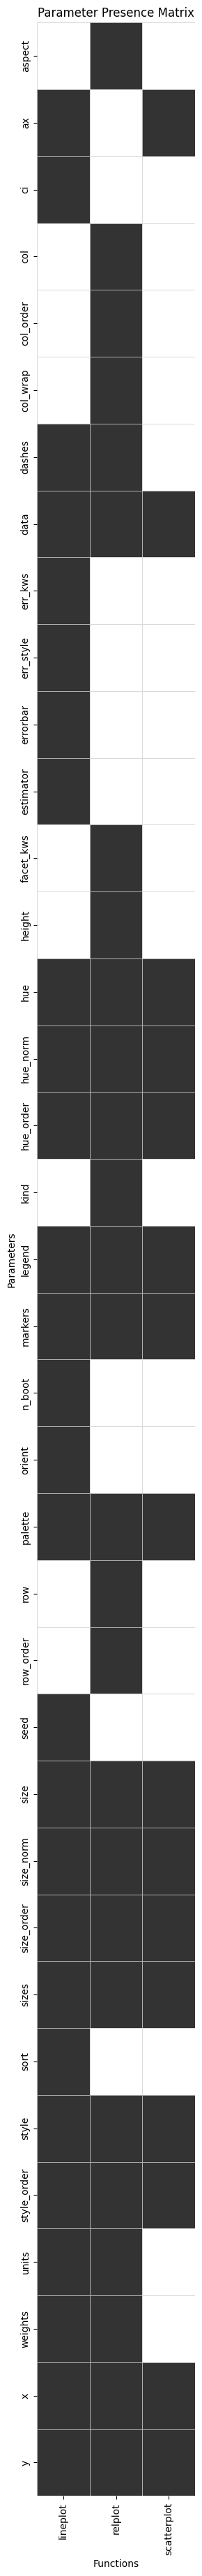

In [ ]:
fig = plot_parameter_matrix(df[(df['kind'] == 'function') &
                               (df['module'] == 'seaborn.relational') &
                               (df['name'].str.contains('[a-z]+plot$')) &
                               (df['prms'].str.contains('data=None'))])

An alternative way to learn about a package is from the documentation available in the internet. As usual, such documentation is made available through many links that sometimes are hard to follow orderly. However, they tend to have a common root link associate with them. The following code shows a way to collect all the links with a common root of a websit--in our case, https://seaborn.pydata.org/. Continuing with the previous illustration, I collect links that provide documentation about [Seaborn](https://seaborn.pydata.org/).

In [ ]:
links = [re.sub('^http(s)?', 'https://r.jina.ai/http', link)
         for link in collect_links('https://seaborn.pydata.org/')]